In [2]:
from petra.posterior_chain import PosteriorChain
from petra.make_catalog import make_catalog_mv_normal
from petra.parametric_fits import mv_normal_fit
from petra.utils import make_uniform_prior

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import corner
from scipy.stats import multivariate_normal
from typing import List
from scipy.interpolate import PchipInterpolator
from petra.utils import process_array

import jax
import jax.numpy as jnp
from scipy.stats import norm
from jax import grad, vmap, jit
jax.config.update("jax_enable_x64", True)
import json
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
with open('/Users/aaron/Documents/nanograv/forks/petra_catalogs/example_notebooks/two_sinusoid/two_sine_results/cold_chains/sine_realization_0/chain_0.txt', 'r') as f:
    chain = np.loadtxt(f)[5000:,:-4]
with open('/Users/aaron/Documents/nanograv/forks/petra_catalogs/example_notebooks/two_sinusoid/two_sine_results/answers/sine_realization_0.json', 'r') as f:
    true_params = json.load(f)

In [14]:
chain.shape

(15000, 6)

In [15]:
# posterior_chain = PosteriorChain.read_feather('./lisa_example.feather')
posterior_chain = PosteriorChain(chain, num_sources=2, num_params_per_source=3)
relabeled_chain = make_catalog_mv_normal(posterior_chain, posterior_chain.num_sources, initialization_param_index=0)

Initializing with univariate normal distribution.

Sorting the posterior chain:
	Maximum number of iterations: 200
	Maximum number of source labels: 2

relabeling samples...


100%|██████████| 15000/15000 [00:00<00:00, 59997.14it/s]


updating parametric fit and probabilities in model...
updating cost of assignment...
Iteration 1: Difference in cost of assignment is -8.597719289223603 with total cost of -8.597719289223603.
	Probabilities in model: [0.99 0.99]
relabeling samples...


100%|██████████| 15000/15000 [00:00<00:00, 65252.56it/s]


updating parametric fit and probabilities in model...
updating cost of assignment...
Iteration 2: Difference in cost of assignment is -13.173306575881389 with total cost of -21.771025865104992.
	Probabilities in model: [0.99 0.99]
relabeling samples...


...

updating parametric fit and probabilities in model...
updating cost of assignment...
Iteration 3: Difference in cost of assignment is 0.0 with total cost of -21.771025865104992.
	Probabilities in model: [0.99 0.99]
Stopped after 3 iterations because the cost didn't change from the previous iteration.
Relabeling with multivariate normal distribution.

Sorting the posterior chain:
	Maximum number of iterations: 200
	Maximum number of source labels: 2

relabeling samples...


100%|██████████| 15000/15000 [00:00<00:00, 35002.06it/s]


updating parametric fit and probabilities in model...
updating cost of assignment...
Iteration 1: Difference in cost of assignment is -33.004508836764835 with total cost of -33.004508836764835.
	Probabilities in model: [0.99 0.99]
relabeling samples...


100%|██████████| 15000/15000 [00:00<00:00, 37957.57it/s]


updating parametric fit and probabilities in model...
updating cost of assignment...
Iteration 2: Difference in cost of assignment is 0.0 with total cost of -33.004508836764835.
	Probabilities in model: [0.99 0.99]
Stopped after 2 iterations because the cost didn't change from the previous iteration.


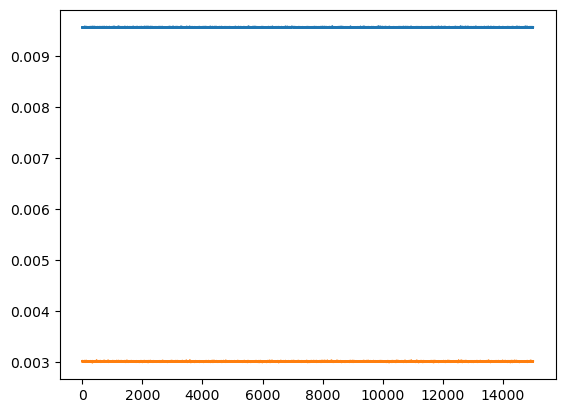

In [19]:
plt.plot(relabeled_chain[:, 1, 0])
plt.plot(relabeled_chain[:, 0, 0])

In [20]:
def make_empirical_cdf_spline(x_grid, samples):
    # 1. Sort the grid
    x_grid = np.asarray(x_grid)
    sort_idx = np.argsort(x_grid)
    xg       = x_grid[sort_idx]

    # 2. Empirical CDF/
    sorted_chain = process_array(samples)
    counts       = np.searchsorted(sorted_chain, xg, side='right')
    cdf_vals     = counts / len(sorted_chain)

    # 3. Monotonic spline, no extrapolation
    try:
        # check for duplicate values and perturb them if there are any:

        cs = PchipInterpolator(xg, cdf_vals, extrapolate=False)
    except ValueError:
        plt.plot(xg, cdf_vals)
        plt.show()

    # 4. Safe wrapper for true CDF
    def cdf_fn(u):
        y = cs(u)
        y = np.where(u < xg[0], 0.0, y)
        y = np.where(u > xg[-1], 1.0, y)
        return y

    # 5. PDF spline
    pdf_spline = cs.derivative()

    def pdf_fn(u):
        y = pdf_spline(u)
        y = np.where(u < xg[0], 1e-20, y)
        y = np.where(u > xg[-1], 1e-20, y)
        return y

    # Return raw CDF values (in the same order as x_grid),
    # the safe CDF function, and the PDF spline
    return (
        cdf_vals[np.argsort(sort_idx)],  # back in original x_grid order
        cdf_fn,
        pdf_fn
    )

def make_transform_marginal_to_gaussian(chain, num_points=200):
    clean_chain = chain[~np.isnan(chain)]
    x = np.quantile(clean_chain, np.linspace(0, 1, num_points))
    raw_cdf, cdf_fn, pdf_fn = make_empirical_cdf_spline(x, clean_chain)

    def transform_marginal_to_gaussian(samples):
        clean_samples = samples[~np.isnan(samples)]
        eps = 1e-6
        clipped_cdf = np.clip(cdf_fn(clean_samples), eps, 1 - eps)
        jacobian_x = pdf_fn(clipped_cdf)
        z = norm.ppf(clipped_cdf)
        jacobian_z = norm.pdf(z)
        log_jacobian = np.log(jacobian_x) - np.log(jacobian_z)
        return z, log_jacobian

    return transform_marginal_to_gaussian

class GaussianCopula:
    def __init__(self, chain_entry: np.ndarray):
        self.marginal_transforms = []
        transformed_samples_list = []
        for parameter_idx in range(chain_entry.shape[1]):
            chain = chain_entry[:, parameter_idx]
            clean_chain = chain[~np.isnan(chain)]

            self.marginal_transforms.append(make_transform_marginal_to_gaussian(clean_chain))
            transformed_samples_list.append(self.marginal_transforms[parameter_idx](clean_chain)[0])

        transformed_samples = np.vstack(transformed_samples_list).T

        mean = np.mean(transformed_samples, axis=0)
        covariance = np.cov(transformed_samples.T)
        self.fit_parameters = (mean, covariance)

    def transform_sample_jacobian(self, sample: np.ndarray):
        if len(sample) != len(self.marginal_transforms):
            raise IndexError("Number of sample indices doesn't match number of marginal transforms.")
        transformed_sample = np.zeros_like(sample)
        total_log_jacobian = 0.0
        for i in range(len(self.marginal_transforms)):
            transformed_parameter, log_jacobian = self.marginal_transforms[i](sample[i])
            transformed_sample[i] = transformed_parameter[0]
            total_log_jacobian += log_jacobian[0]
        return transformed_sample, total_log_jacobian

    def log_prob(self, sample: np.ndarray) -> np.ndarray:
        if np.any(np.isnan(sample)):
            raise ValueError("Sample contain NaNs.")
        transformed_sample, log_jacobian = self.transform_sample_jacobian(sample)
        return multivariate_normal(mean=self.fit_parameters[0], cov=self.fit_parameters[1]).logpdf(transformed_sample) + log_jacobian

    # __call__ = log_prob  # maybe not needed

def make_fit_gaussian_copulas(chain):

    uniform_prior = make_uniform_prior(chain)

    def fit_gaussian_copulas(chain: np.ndarray, max_num_sources: int, min_pts_fit=8) -> List[GaussianCopula]:
        copula_list = []
        for source_idx in range(max_num_sources):
            chain_freqs = chain[:, source_idx, 0]
            if len(chain_freqs[~np.isnan(chain_freqs)]) < min_pts_fit:
                copula_list.append(uniform_prior)
            else:
                copula_list.append(GaussianCopula(chain[:, source_idx, :]))
        return copula_list

    return fit_gaussian_copulas

def gaussian_copula_aux_distribution(sample: np.ndarray,
                                     aux_parameters: List,
                                     source_index) -> np.ndarray:
    source_indices = np.atleast_1d(source_index)
    cost_matrix = np.zeros((len(source_indices), len(aux_parameters)))
    for source_idx in source_indices:
        if np.any(np.isnan(sample[source_idx])):
            cost_matrix[source_idx, :] = np.nan
            continue
        for aux_idx in range(len(aux_parameters)):
            cost_matrix[source_idx, aux_idx] = aux_parameters[aux_idx].log_prob(sample[source_idx]) + 1e-10
    return cost_matrix.T


In [21]:
from petra.relabel import create_relabel_samples

def relabel_gaussian_copula(posterior_chain: PosteriorChain,
                              max_num_sources: int|None = None,
                              num_iterations: int = 20,
                              eps=1e-2):
    fit_gaussian_copulas = make_fit_gaussian_copulas(posterior_chain.chain)
    relabel_samples = create_relabel_samples(fit_gaussian_copulas,
                                             gaussian_copula_aux_distribution,
                                             eps=eps)

    return relabel_samples(
        posterior_chain,
        max_num_sources=max_num_sources,
        num_iterations=num_iterations
    )


def make_catalog_gaussian_copula(posterior_chain: PosteriorChain,
                                   max_num_sources: int,
                                   num_iterations: int = 200):

    if posterior_chain.num_sources > max_num_sources:
        raise ValueError("max_num_sources must be greater than the number of entries in the chain.")

    # make sure that posterior_chain has the right shape
    if posterior_chain.num_sources < max_num_sources:
        print("Expanding posterior chain to max_num_sources.")
        posterior_chain.expand_chain(max_num_sources)

    else:
        initial_posterior_chain = posterior_chain

    # relabel using mv normal
    print("Relabeling with normalizing flows.")
    relabeled_chain = relabel_gaussian_copula(initial_posterior_chain,
                                            max_num_sources=max_num_sources,
                                            num_iterations=num_iterations)

    return relabeled_chain

In [ ]:
new_pc = make_catalog_gaussian_copula(posterior_chain, max_num_sources=relabeled_chain.shape[1], num_iterations=10)

Relabeling with normalizing flows.

Sorting the posterior chain:
	Maximum number of iterations: 10
	Maximum number of source labels: 2

relabeling samples...


100%|██████████| 15000/15000 [00:16<00:00, 897.78it/s]


updating parametric fit and probabilities in model...
updating cost of assignment...
Iteration 1: Difference in cost of assignment is 203.2726347249239 with total cost of 203.2726347249239.
	Probabilities in model: [0.99 0.99]
relabeling samples...


100%|██████████| 15000/15000 [00:16<00:00, 902.53it/s]


updating parametric fit and probabilities in model...
updating cost of assignment...
Iteration 2: Difference in cost of assignment is -4.660653497024725 with total cost of 198.61198122789918.
	Probabilities in model: [0.99 0.99]
relabeling samples...


...

updating parametric fit and probabilities in model...
updating cost of assignment...
Iteration 8: Difference in cost of assignment is -1.163750932990439 with total cost of 201.66720135583722.
	Probabilities in model: [0.99 0.99]
relabeling samples...


100%|██████████| 15000/15000 [00:17<00:00, 874.60it/s]


updating parametric fit and probabilities in model...
updating cost of assignment...
Iteration 9: Difference in cost of assignment is -1.6743418476730199 with total cost of 199.9928595081642.
	Probabilities in model: [0.99 0.99]
relabeling samples...


100%|██████████| 15000/15000 [00:17<00:00, 871.57it/s]


updating parametric fit and probabilities in model...
updating cost of assignment...
Iteration 10: Difference in cost of assignment is 0.2747771510275072 with total cost of 200.2676366591917.
	Probabilities in model: [0.99 0.99]
Final cost of assignment: 200.2676366591917 after the maximum number (10) of iterations.


(array([  2.,   0.,   1.,   4.,   9.,   5.,   6.,  11.,  18.,  23.,  46.,
         54.,  47., 115., 126., 175., 204., 286., 379., 387., 398., 598.,
        748., 294., 220., 233., 282., 431., 329., 318., 394., 304., 251.,
        214., 206., 174., 141.,  82.,  67.,  44.,  32.,  14.,   9.,   9.,
          8.,   4.,   4.,   4.,   3.,   6.,   8.,  15.,  22.,  24.,  41.,
         63.,  82.,  90., 138., 138., 217., 265., 259., 201.,  60.,   6.,
          2.,  14., 185.,  96., 108., 230., 438., 592., 656., 691., 634.,
        584., 446., 310., 195., 101.,  28.,  27.,  67.,  66.,  46.,  52.,
         34.,  14.,  15.,   8.,   5.,   2.,   0.,   3.,   2.,   0.,   0.,
          1.]),
 array([0.19115704, 0.19884231, 0.20652758, 0.21421285, 0.22189812,
        0.22958339, 0.23726867, 0.24495394, 0.25263921, 0.26032448,
        0.26800975, 0.27569502, 0.2833803 , 0.29106557, 0.29875084,
        0.30643611, 0.31412138, 0.32180665, 0.32949192, 0.3371772 ,
        0.34486247, 0.35254774, 0.36023301, 0.

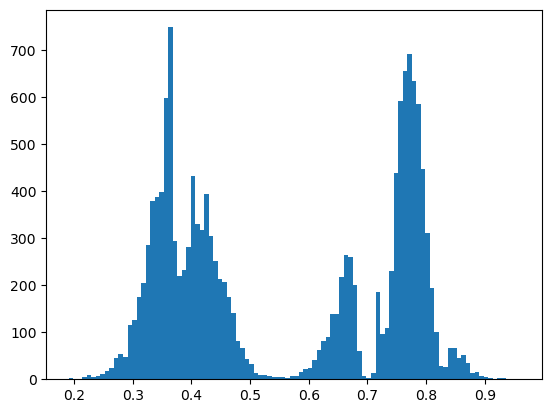

In [ ]:
plt.hist(new_pc[:, 0, 2], bins=100)

In [28]:
np.random.seed(0)
chain = np.zeros((10_000, 2))
chain_signal_1 = np.random.uniform(0, 1, 10000)
chain_signal_2 = np.random.uniform(0, 1, 10000)
chain[::2, 0] = chain_signal_1[::2]
chain[1::2, 0] = np.nan
chain[1::2, 1] = chain_signal_2[1::2]
chain[::2, 1] = np.nan
pc = PosteriorChain(chain, 2, 1)

In [23]:
new_pc2 = make_catalog_gaussian_copula(pc, max_num_sources=pc.shape[1], num_iterations=20)

NameError: name 'pc' is not defined